# Week 03, 05, 06 : 지수·정현파 신호, 기본 함수, 시스템 성질 & LTI 시스템

**신호 및 시스템 (Signals and Systems)**

이번 실습에서는 Week 3, 5, 6에서 다룬 핵심 개념들을 Python으로 확인합니다.

### 학습 목표
1. **지수 신호와 정현파 신호 (Exponential & Sinusoidal Signals)** — 오일러 공식, 복소 지수 신호, 조화 관계 복소 지수를 이해한다.
2. **이산시간 복소 지수의 주기성 (Periodicity of DT Complex Exponentials)** — 연속시간과의 차이를 파악한다.
3. **단위 임펄스 & 단위 계단 함수 (Unit Impulse & Unit Step)** — δ[n], u[n], δ(t), u(t)를 시각화하고 관계를 이해한다.
4. **시스템의 기본 성질 (Basic System Properties)** — 선형성, 시불변성, 인과성, 안정성을 실습으로 검증한다.
5. **LTI 시스템과 컨볼루션 (LTI Systems & Convolution)** — 컨볼루션 합(Convolution Sum)의 원리를 이해하고 직접 계산한다.

---

In [ ]:
## 필요한 라이브러리 설치 (최초 1회만 실행)
!pip3 install numpy matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

---
## 1. 지수 신호와 정현파 신호 (Week 3)

### 1.1 오일러 공식 (Euler's Formula)

$$e^{j\omega_0 t} = \cos(\omega_0 t) + j\sin(\omega_0 t)$$

이로부터 코사인과 사인을 복소 지수로 표현할 수 있습니다:

$$\cos(\omega_0 t) = \text{Re}\{e^{j\omega_0 t}\}, \quad \sin(\omega_0 t) = \text{Im}\{e^{j\omega_0 t}\}$$

$$A\cos(\omega_0 t + \varphi) = \frac{A}{2}e^{j\varphi}e^{j\omega_0 t} + \frac{A}{2}e^{-j\varphi}e^{-j\omega_0 t}$$

> 오일러 공식은 복소 지수 신호와 정현파 신호를 연결하는 핵심 도구입니다.

### 예제 1-1: 오일러 공식 시각화

복소 지수 $e^{j\omega_0 t}$의 실수부(cos)와 허수부(sin)를 함께 그려봅시다.

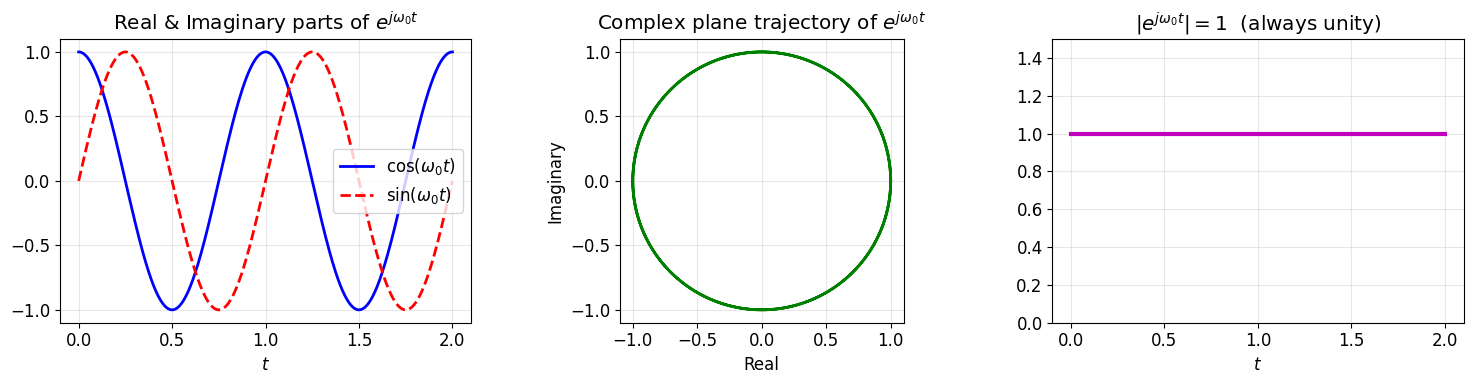

In [2]:
omega0 = 2 * np.pi  # fundamental angular frequency (rad/s)
t = np.linspace(0, 2, 1000)

z = np.exp(1j * omega0 * t)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, z.real, 'b-', label=r'$\cos(\omega_0 t)$')
axes[0].plot(t, z.imag, 'r--', label=r'$\sin(\omega_0 t)$')
axes[0].set_title(r'Real & Imaginary parts of $e^{j\omega_0 t}$')
axes[0].set_xlabel('$t$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 복소 평면에서의 궤적
axes[1].plot(z.real, z.imag, 'g-')
axes[1].set_title(r'Complex plane trajectory of $e^{j\omega_0 t}$')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

# |e^{jω₀t}| = 1 확인
axes[2].plot(t, np.abs(z), 'm-', linewidth=3)
axes[2].set_title(r'$|e^{j\omega_0 t}| = 1$  (always unity)')
axes[2].set_xlabel('$t$')
axes[2].set_ylim(0, 1.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 정현파 신호 — 주파수와 위상

$$x(t) = A\cos(\omega_0 t + \varphi)$$

- $A$: 진폭 (Amplitude)
- $\omega_0$: 각주파수 (Angular frequency, rad/s)
- $\varphi$: 위상 (Phase offset)
- 기본 주기: $T_0 = \frac{2\pi}{\omega_0}$, 기본 주파수: $f_0 = \frac{\omega_0}{2\pi}$ Hz

> $\omega_0$가 클수록 진동이 빠르고, 주기 $T_0$가 짧아집니다.

### 예제 1-2: 주파수에 따른 정현파 비교

서로 다른 $\omega_0$ 값을 갖는 정현파들을 비교합니다.

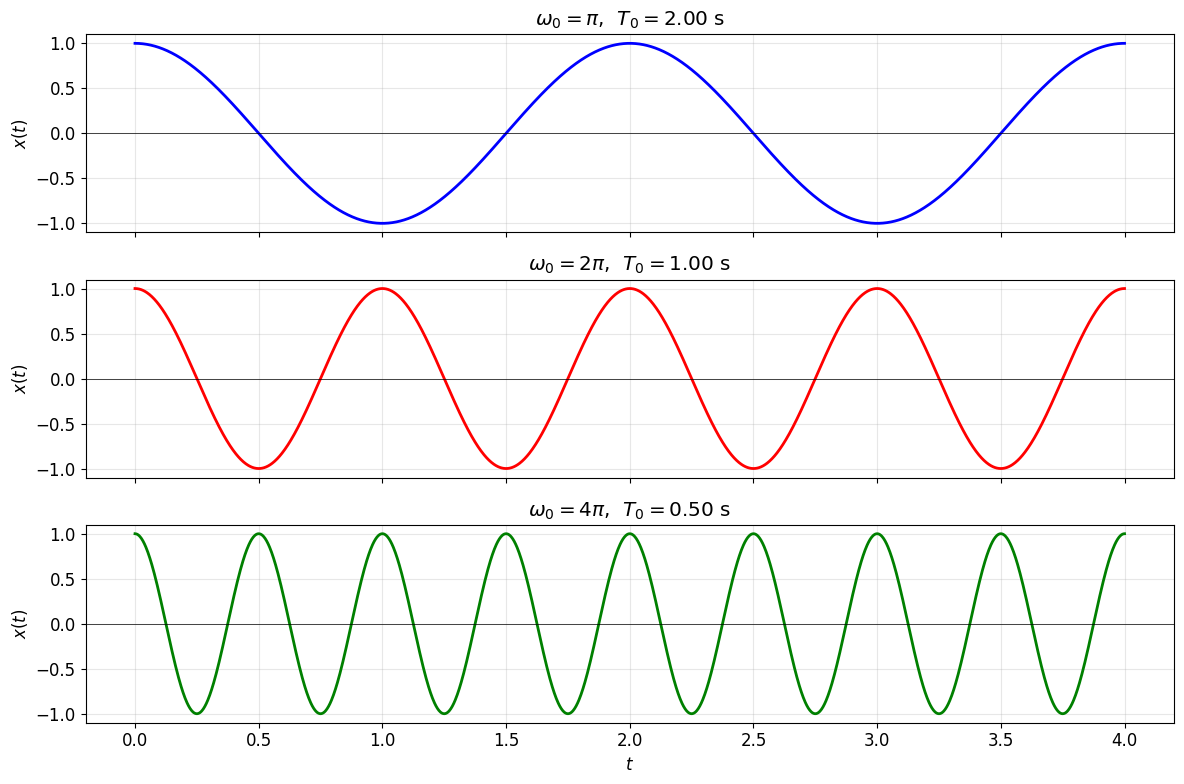

→ ω₀가 커질수록 진동 빈도가 높아지고, 주기가 짧아짐을 확인!


In [3]:
t = np.linspace(0, 4, 2000)

omegas = [np.pi, 2*np.pi, 4*np.pi]
labels = [r'$\omega_0 = \pi$', r'$\omega_0 = 2\pi$', r'$\omega_0 = 4\pi$']
colors = ['b', 'r', 'g']

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (w, lbl, c) in enumerate(zip(omegas, labels, colors)):
    T0 = 2 * np.pi / w
    axes[i].plot(t, np.cos(w * t), color=c)
    axes[i].set_title(f'{lbl},  $T_0 = {T0:.2f}$ s')
    axes[i].set_ylabel('$x(t)$')
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(y=0, color='k', linewidth=0.5)

axes[-1].set_xlabel('$t$')
plt.tight_layout()
plt.show()

print("→ ω₀가 커질수록 진동 빈도가 높아지고, 주기가 짧아짐을 확인!")

### 1.3 일반 복소 지수 신호 (General Complex Exponential)

$$Ce^{at} = |C|e^{rt}\cos(\omega_0 t + \theta) + j|C|e^{rt}\sin(\omega_0 t + \theta)$$

여기서 $C = |C|e^{j\theta}$, $a = r + j\omega_0$ 입니다.

| $r$의 값 | 신호의 형태 |
|----------|------------|
| $r = 0$  | 순수 정현파 |
| $r > 0$  | **증가**하는 정현파 (Growing) |
| $r < 0$  | **감소**하는 정현파 (Decaying) |

### 예제 1-3: 감쇠/증가 정현파

$r$의 부호에 따라 지수함수 × 정현파의 형태가 어떻게 변하는지 확인합니다.

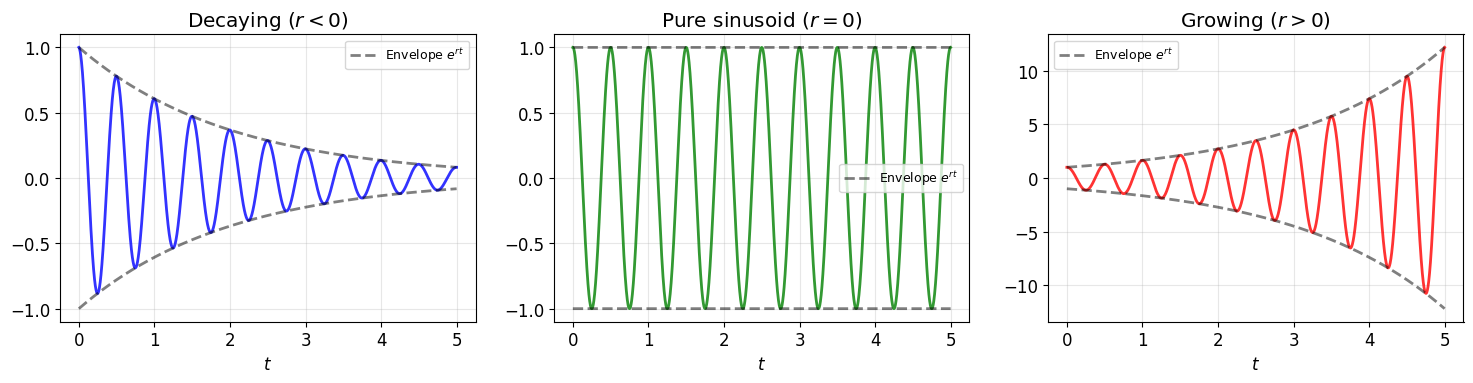

In [4]:
t = np.linspace(0, 5, 2000)
omega0 = 4 * np.pi

r_values = [-0.5, 0, 0.5]
titles = [r'Decaying ($r < 0$)', r'Pure sinusoid ($r = 0$)', r'Growing ($r > 0$)']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (r, title, c) in enumerate(zip(r_values, titles, colors)):
    x = np.exp(r * t) * np.cos(omega0 * t)
    envelope = np.exp(r * t)
    axes[i].plot(t, x, color=c, alpha=0.8)
    axes[i].plot(t, envelope, 'k--', alpha=0.5, label='Envelope $e^{rt}$')
    axes[i].plot(t, -envelope, 'k--', alpha=0.5)
    axes[i].set_title(title)
    axes[i].set_xlabel('$t$')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4 조화 관계 복소 지수 (Harmonically Related Complex Exponentials)

기본 주기 $T_0$를 공유하는 복소 지수 집합:

$$\phi_k(t) = e^{jk\omega_0 t}, \quad k = 0, \pm1, \pm2, \ldots$$

- 모두 같은 주기 $T_0$를 공유합니다.
- 주파수는 기본 주파수 $\omega_0$의 **정수배**입니다.
- $k=0$이면 상수 (DC 성분), $k \neq 0$이면 기본 주기 $T_0/|k|$를 갖습니다.

> 실제 소리는 기본 주파수 + 그 정수배 주파수들의 합(superposition)으로 구성됩니다.

### 예제 1-4: 조화 성분(Harmonics) 시각화

기본 주파수 $f_0 = 1$ Hz에 대해 $k=1,2,3,4$번째 조화 성분의 실수부(코사인)를 시각화합니다.

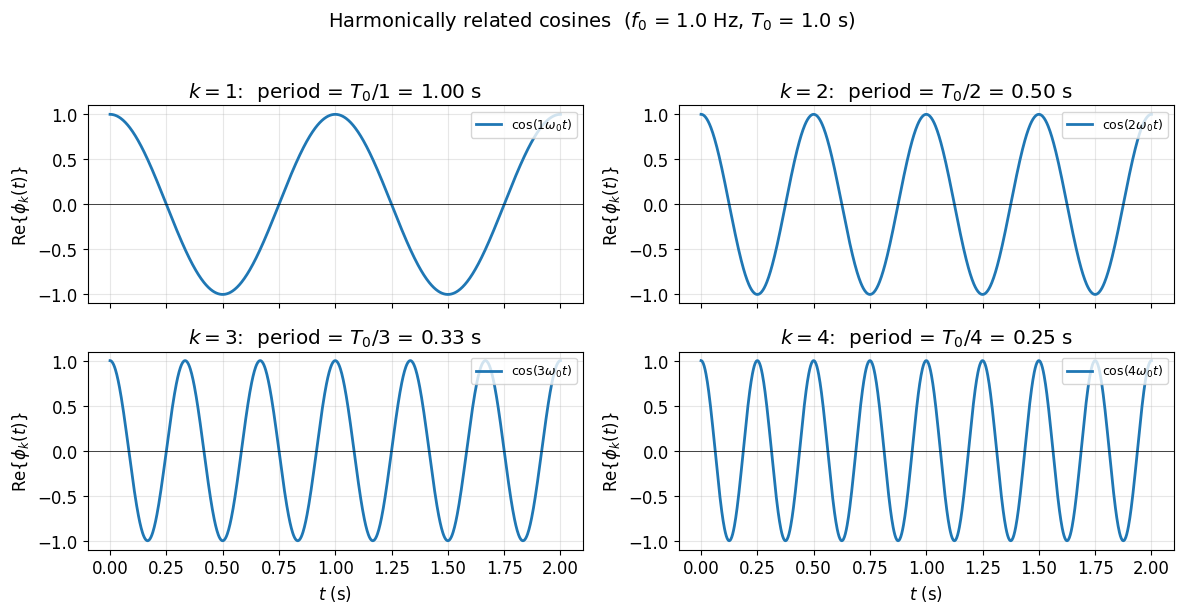

→ 모든 성분의 주기가 T₀ = 1.0s의 약수임을 확인!


In [5]:
f0 = 1.0
omega0 = 2 * np.pi * f0
T0 = 1.0 / f0
t = np.linspace(0, 2 * T0, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

for idx, k in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2, idx % 2]
    phi_k = np.exp(1j * k * omega0 * t)
    ax.plot(t, phi_k.real, label=f'$\\cos({k}\\omega_0 t)$')
    ax.set_title(f'$k = {k}$:  period = $T_0/{k}$ = {T0/k:.2f} s')
    ax.set_ylabel('$\\mathrm{Re}\{\\phi_k(t)\}$')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)

for ax in axes[1]:
    ax.set_xlabel('$t$ (s)')

plt.suptitle(f'Harmonically related cosines  ($f_0$ = {f0} Hz, $T_0$ = {T0} s)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"→ 모든 성분의 주기가 T₀ = {T0}s의 약수임을 확인!")

---
## 2. 이산시간 복소 지수의 주기성 (Week 3)

### 연속시간 vs 이산시간의 핵심 차이

| 성질 | 연속시간 $e^{j\omega_0 t}$ | 이산시간 $e^{j\omega_0 n}$ |
|------|---------------------------|---------------------------|
| **주파수 구분** | 모든 $\omega_0$에 대해 서로 다른 신호 | 주파수 $\omega_0$와 $\omega_0 + 2\pi$는 **동일** |
| **진동 속도** | $\lvert\omega_0\rvert$ ↑ → 항상 더 빠름 | $\omega_0 = \pi$에서 가장 빠름, 이후 **느려짐** |
| **주기성** | 모든 $\omega_0$에서 주기 | $\omega_0/(2\pi)$가 **유리수**일 때만 주기 |

> 이산시간에서는 $e^{j(\omega_0 + 2\pi)n} = e^{j2\pi n}e^{j\omega_0 n} = e^{j\omega_0 n}$ 이므로, 주파수에 $2\pi$ 주기성이 존재합니다.

### 예제 2-1: 이산시간에서 $\omega_0$ 증가에 따른 진동 변화

$\omega_0$를 0에서 $2\pi$까지 변화시키면서, $\omega_0 = \pi$에서 진동이 가장 빠르고 이후 느려지는 것을 확인합니다.

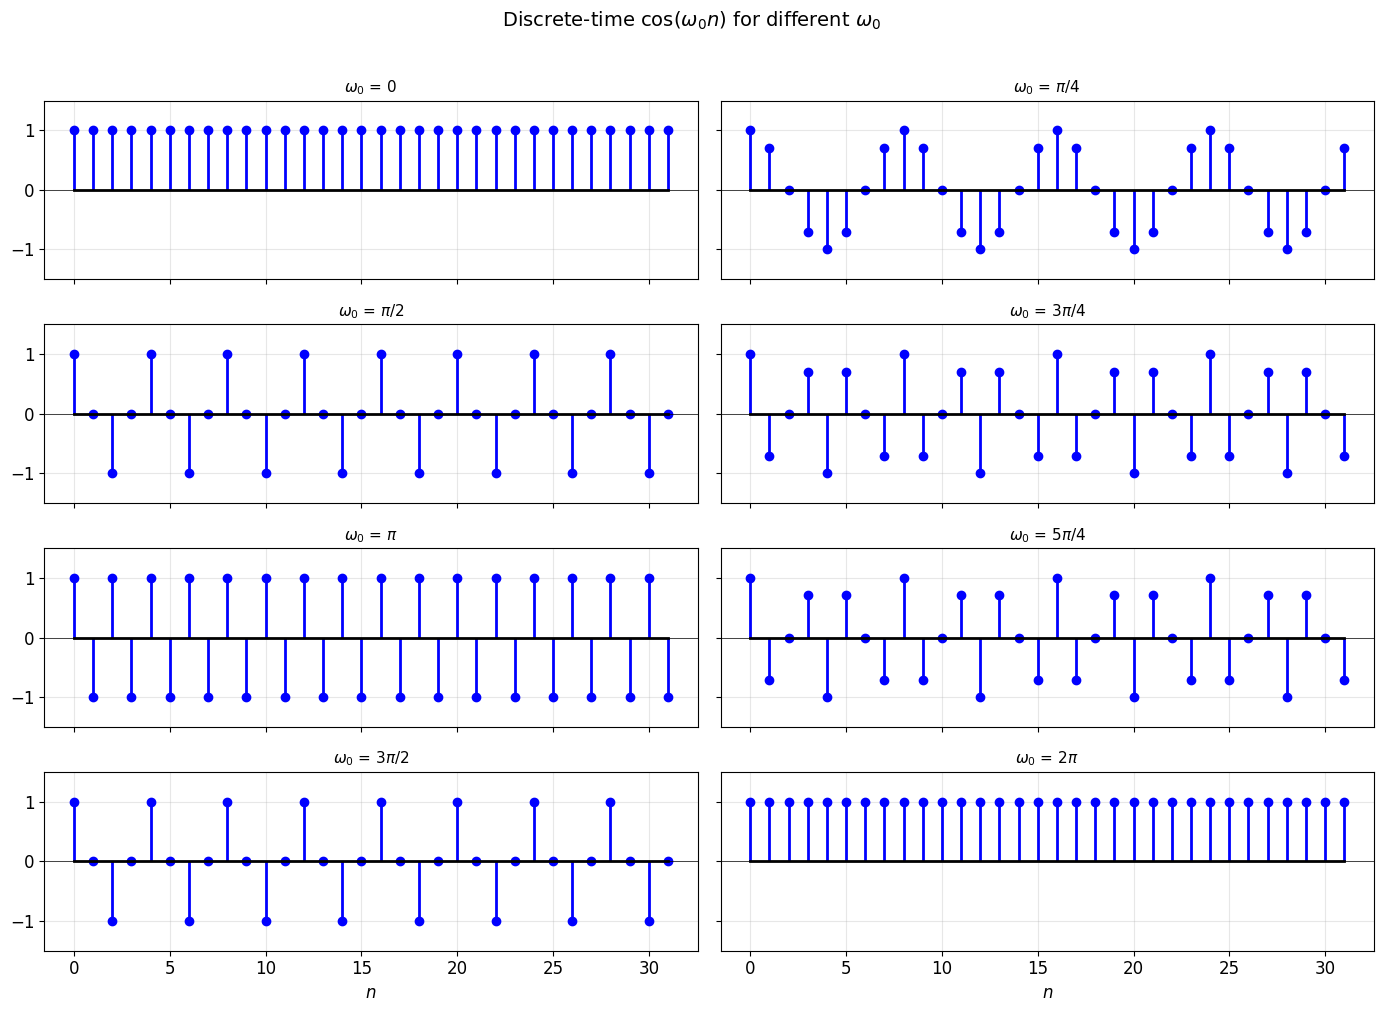

→ ω₀ = π에서 진동이 가장 빠르고 (cos(πn) = (-1)^n), ω₀ = 2π에서 다시 상수가 됨!
→ 이것이 이산시간 복소 지수의 2π 주기성!


In [6]:
n = np.arange(0, 32)

omega_values = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 2*np.pi]
omega_labels = ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$2\pi$']

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True, sharey=True)

for idx, (w, lbl) in enumerate(zip(omega_values, omega_labels)):
    ax = axes[idx // 2, idx % 2]
    x_n = np.cos(w * n)
    ax.stem(n, x_n, linefmt='b-', markerfmt='bo', basefmt='k-')
    ax.set_title(f'$\\omega_0$ = {lbl}', fontsize=11)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)

for ax in axes[-1]:
    ax.set_xlabel('$n$')

plt.suptitle(r'Discrete-time $\cos(\omega_0 n)$ for different $\omega_0$', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("→ ω₀ = π에서 진동이 가장 빠르고 (cos(πn) = (-1)^n), ω₀ = 2π에서 다시 상수가 됨!")
print("→ 이것이 이산시간 복소 지수의 2π 주기성!")

### 예제 2-2: 이산시간 주기 함수 판별

$e^{j\omega_0 n}$이 주기 함수이려면:

$$\frac{\omega_0}{2\pi} = \frac{m}{N} \quad \text{(유리수)}$$

이 때 기본 주기 $N$은 위 등식을 만족하는 **최소 양의 정수** 입니다.

- $x[n] = \cos(8\pi n / 31)$ → $\omega_0/(2\pi) = 4/31$ → **주기** $N = 31$
- $x[n] = \cos(n/6)$ → $\omega_0/(2\pi) = 1/(12\pi)$ → **무리수** → **비주기**

cos(8πn/31): ω₀/(2π) = 4/31 (유리수) → 주기 함수, 기본 주기 N = 31
cos(n/6): ω₀/(2π) ≈ 0.026526 (무리수) → 비주기 함수


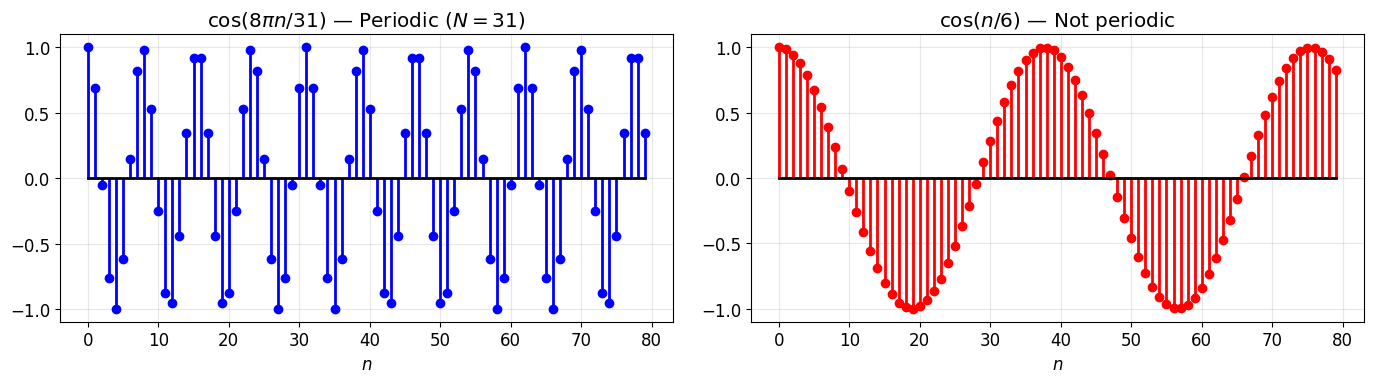

In [7]:
from fractions import Fraction

def check_dt_periodicity(omega0, label=''):
    ratio = omega0 / (2 * np.pi)
    frac = Fraction(ratio).limit_denominator(1000)
    
    # 유리수 근사가 원래 값과 매우 가까운지 확인
    if abs(float(frac) - ratio) < 1e-10:
        N = frac.denominator
        print(f"{label}: ω₀/(2π) = {frac} (유리수) → 주기 함수, 기본 주기 N = {N}")
        return True, N
    else:
        print(f"{label}: ω₀/(2π) ≈ {ratio:.6f} (무리수) → 비주기 함수")
        return False, None

# Case 1: cos(8πn/31)
is_periodic1, N1 = check_dt_periodicity(8*np.pi/31, "cos(8πn/31)")

# Case 2: cos(n/6)
is_periodic2, N2 = check_dt_periodicity(1/6, "cos(n/6)")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

n = np.arange(0, 80)

x1 = np.cos(8 * np.pi * n / 31)
axes[0].stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title(r'$\cos(8\pi n / 31)$ — Periodic ($N=31$)')
axes[0].set_xlabel('$n$')
axes[0].grid(True, alpha=0.3)

x2 = np.cos(n / 6)
axes[1].stem(n, x2, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(r'$\cos(n/6)$ — Not periodic')
axes[1].set_xlabel('$n$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 단위 임펄스 & 단위 계단 함수 (Week 5)

### 3.1 이산시간 단위 임펄스와 단위 계단

$$\delta[n] = \begin{cases} 1, & n = 0 \\ 0, & n \neq 0 \end{cases}, \qquad u[n] = \begin{cases} 1, & n \geq 0 \\ 0, & n < 0 \end{cases}$$

### 관계식

$$\delta[n] = u[n] - u[n-1]$$

$$u[n] = \sum_{k=0}^{\infty} \delta[n-k] = \sum_{k=-\infty}^{n} \delta[k]$$

### 샘플링 성질 (Sampling Property)

$$x[n]\delta[n] = x[0]\delta[n], \qquad x[n]\delta[n - n_0] = x[n_0]\delta[n - n_0]$$

### 예제 3-1: δ[n]과 u[n] 시각화 및 관계 확인

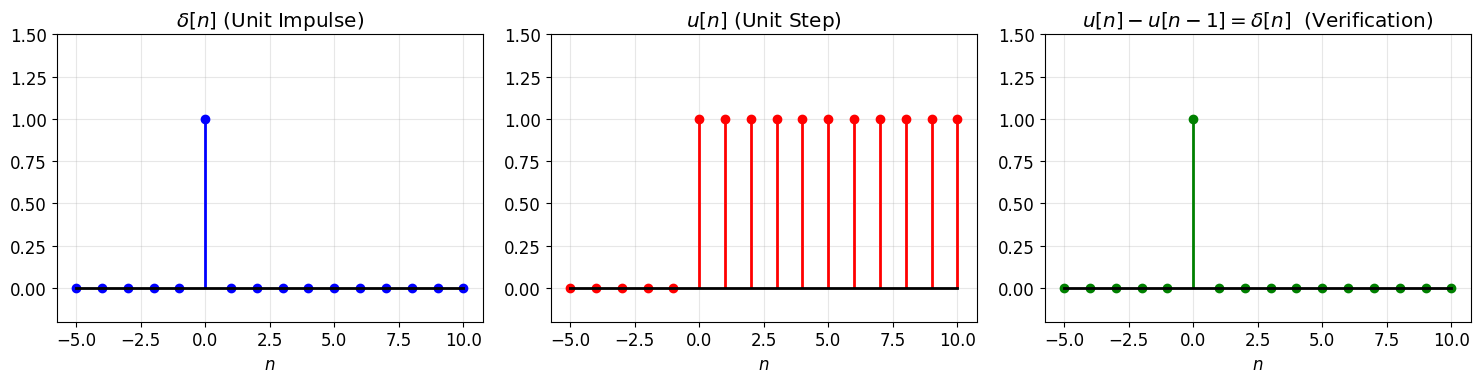

→ δ[n] = u[n] − u[n−1] 관계가 성립함을 확인!


In [8]:
def delta(n):
    """Discrete-time unit impulse"""
    return np.where(n == 0, 1.0, 0.0)

def unit_step(n):
    """Discrete-time unit step"""
    return np.where(n >= 0, 1.0, 0.0)

n = np.arange(-5, 11)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# δ[n]
axes[0].stem(n, delta(n), linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title(r'$\delta[n]$ (Unit Impulse)')
axes[0].set_xlabel('$n$')
axes[0].set_ylim(-0.2, 1.5)
axes[0].grid(True, alpha=0.3)

# u[n]
axes[1].stem(n, unit_step(n), linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(r'$u[n]$ (Unit Step)')
axes[1].set_xlabel('$n$')
axes[1].set_ylim(-0.2, 1.5)
axes[1].grid(True, alpha=0.3)

# δ[n] = u[n] - u[n-1] 확인
reconstructed_delta = unit_step(n) - unit_step(n - 1)
axes[2].stem(n, reconstructed_delta, linefmt='g-', markerfmt='go', basefmt='k-')
axes[2].set_title(r'$u[n] - u[n-1] = \delta[n]$  (Verification)')
axes[2].set_xlabel('$n$')
axes[2].set_ylim(-0.2, 1.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ δ[n] = u[n] − u[n−1] 관계가 성립함을 확인!")

### 3.2 연속시간 단위 계단과 단위 임펄스

$$u(t) = \begin{cases} 0, & t < 0 \\ 1, & t > 0 \end{cases}$$

$\delta(t)$는 고전적인 함수가 아니라 **일반화된 함수(generalized function)** 입니다:

$$u(t) = \int_{-\infty}^{t} \delta(\tau)\,d\tau, \qquad \delta(t) = \frac{du(t)}{dt}$$

실제로는 $\Delta \to 0$인 극한으로 이해합니다:
- $u_\Delta(t)$: 0에서 1로 부드럽게 올라가는 근사 함수
- $\delta_\Delta(t) = \frac{du_\Delta(t)}{dt}$: 면적 1로 고정된 펄스

### 예제 3-2: 연속시간 δ(t) 근사 — $\Delta$를 줄여가며 관찰

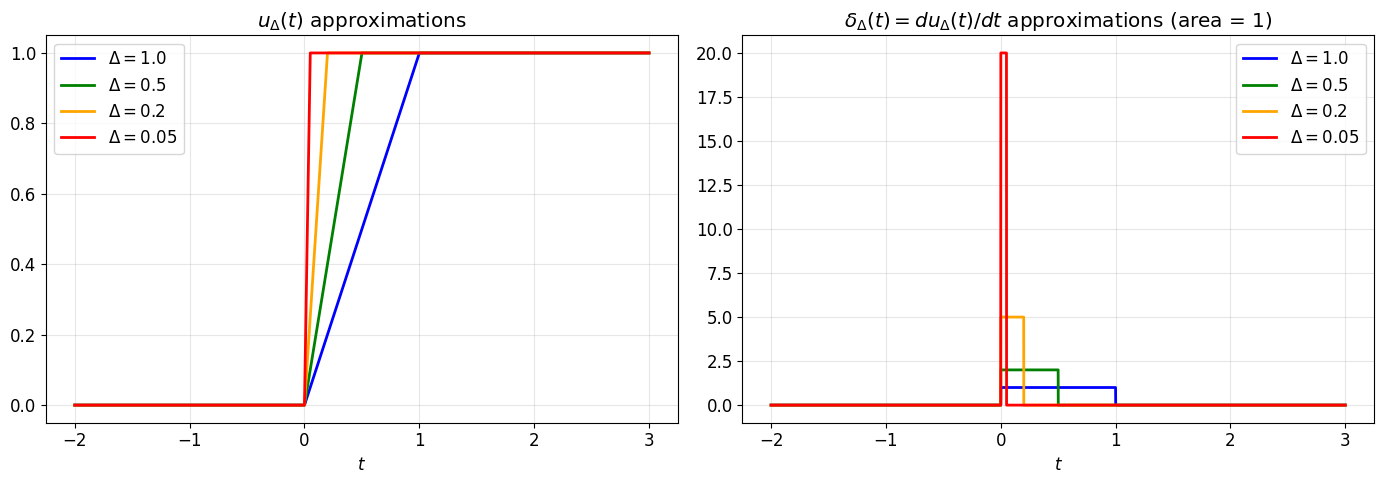

→ Δ → 0 이면 u_Δ(t) → u(t), δ_Δ(t) → δ(t)
→ δ_Δ(t)의 면적은 항상 1로 유지됨!


In [9]:
t = np.linspace(-2, 3, 5000)

def u_approx(t, delta_val):
    """Smooth approximation of unit step over interval [0, delta_val]"""
    return np.where(t < 0, 0.0, np.where(t > delta_val, 1.0, t / delta_val))

def delta_approx(t, delta_val):
    """Rectangular pulse approximation of δ(t) with area = 1"""
    return np.where((t >= 0) & (t <= delta_val), 1.0 / delta_val, 0.0)

deltas = [1.0, 0.5, 0.2, 0.05]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for d, c in zip(deltas, colors):
    axes[0].plot(t, u_approx(t, d), color=c, label=f'$\\Delta = {d}$')
    axes[1].plot(t, delta_approx(t, d), color=c, label=f'$\\Delta = {d}$')

axes[0].set_title(r'$u_\Delta(t)$ approximations')
axes[0].set_xlabel('$t$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title(r'$\delta_\Delta(t) = du_\Delta(t)/dt$ approximations (area = 1)')
axes[1].set_xlabel('$t$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ Δ → 0 이면 u_Δ(t) → u(t), δ_Δ(t) → δ(t)")
print("→ δ_Δ(t)의 면적은 항상 1로 유지됨!")

### 예제 3-3: 샘플링 성질 (Sampling Property)

$x[n] \cdot \delta[n - n_0] = x[n_0] \cdot \delta[n - n_0]$

임의의 신호를 **임펄스들의 가중합**으로 표현할 수 있습니다:

$$x[n] = \sum_{k=-\infty}^{\infty} x[k]\,\delta[n - k]$$

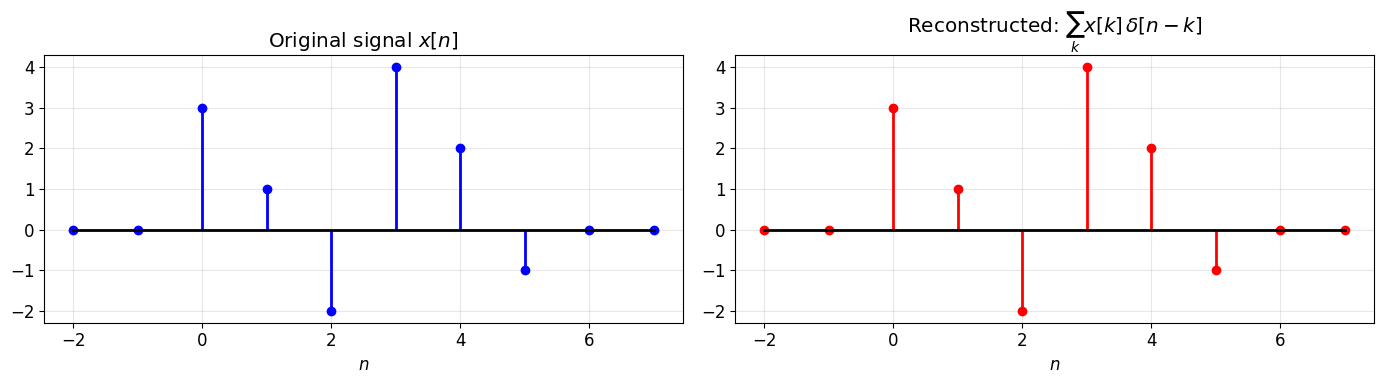

원본과 복원 일치: True
→ 모든 이산시간 신호는 이동된 임펄스들의 가중합으로 표현 가능!


In [10]:
n = np.arange(-2, 8)
x = np.array([0, 0, 3, 1, -2, 4, 2, -1, 0, 0])  # x[-2]..x[7]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 원래 신호
axes[0].stem(n, x, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title(r'Original signal $x[n]$')
axes[0].set_xlabel('$n$')
axes[0].grid(True, alpha=0.3)

# 임펄스 분해
x_reconstructed = np.zeros_like(n, dtype=float)
for k_idx, k_val in enumerate(n):
    x_reconstructed += x[k_idx] * delta(n - k_val)

axes[1].stem(n, x_reconstructed, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(r'Reconstructed: $\sum_k x[k]\,\delta[n-k]$')
axes[1].set_xlabel('$n$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"원본과 복원 일치: {np.allclose(x, x_reconstructed)}")
print("→ 모든 이산시간 신호는 이동된 임펄스들의 가중합으로 표현 가능!")

---
## 4. 시스템의 기본 성질 (Week 5)

시스템 $T\{\cdot\}$에 대해 다음 성질들을 검증합니다:

| 성질 | 정의 |
|------|------|
| **메모리 (Memory)** | 출력이 현재 입력 이외의 값에도 의존하면 memory system |
| **인과성 (Causality)** | 출력이 현재와 과거 입력에만 의존 |
| **안정성 (BIBO Stability)** | 유한 입력 → 항상 유한 출력 |
| **시불변성 (Time Invariance)** | $x(t-t_0)$ 입력 → $y(t-t_0)$ 출력 |
| **선형성 (Linearity)** | $ax_1 + bx_2$ 입력 → $ay_1 + by_2$ 출력 (중첩 원리) |

### 예제 4-1: 선형성(Linearity) 검증

**선형 시스템**: $y(t) = t \cdot x(t)$

**비선형 시스템**: $y(t) = x^2(t)$

선형성 조건: $T\{ax_1 + bx_2\} = aT\{x_1\} + bT\{x_2\}$

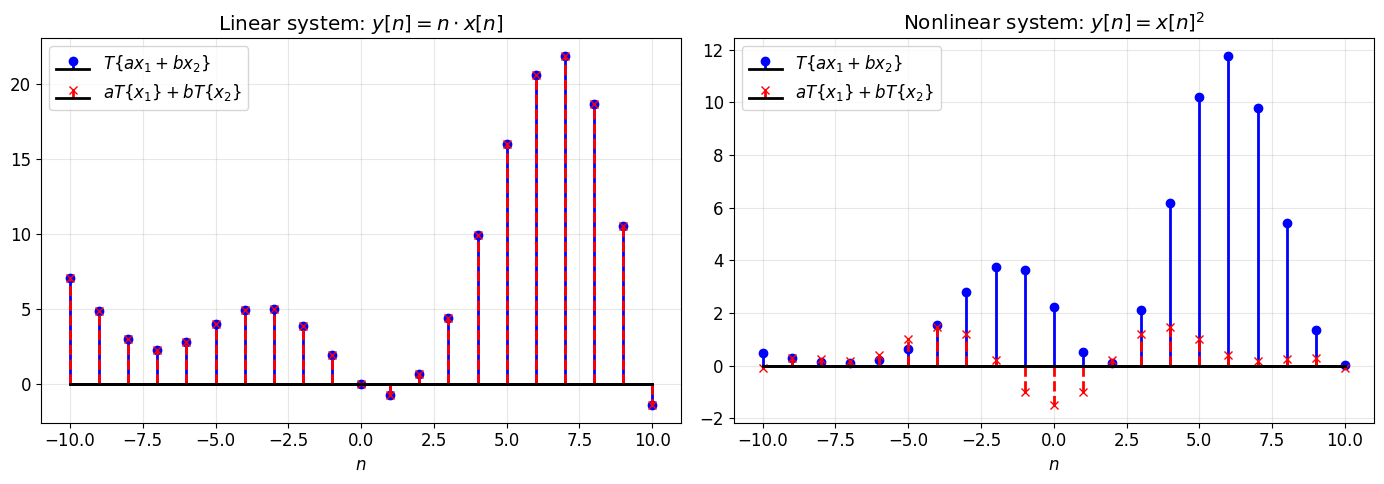

선형 시스템 — 양변 일치: True
비선형 시스템 — 양변 일치: False


In [11]:
n = np.arange(-10, 11)

x1 = np.sin(0.3 * n)
x2 = np.cos(0.5 * n)
a, b = 2.0, -1.5

# 선형 시스템: y[n] = n * x[n]
def linear_sys(x, n):
    return n * x

# 비선형 시스템: y[n] = x[n]^2
def nonlinear_sys(x, n):
    return x ** 2

# --- 선형 시스템 검증 ---
lhs_linear = linear_sys(a * x1 + b * x2, n)     # T{a*x1 + b*x2}
rhs_linear = a * linear_sys(x1, n) + b * linear_sys(x2, n)  # a*T{x1} + b*T{x2}

# --- 비선형 시스템 검증 ---
lhs_nonlinear = nonlinear_sys(a * x1 + b * x2, n)
rhs_nonlinear = a * nonlinear_sys(x1, n) + b * nonlinear_sys(x2, n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].stem(n, lhs_linear, linefmt='b-', markerfmt='bo', basefmt='k-', label='$T\{ax_1+bx_2\}$')
axes[0].stem(n, rhs_linear, linefmt='r--', markerfmt='rx', basefmt='k-', label='$aT\{x_1\}+bT\{x_2\}$')
axes[0].set_title('Linear system: $y[n] = n \cdot x[n]$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('$n$')

axes[1].stem(n, lhs_nonlinear, linefmt='b-', markerfmt='bo', basefmt='k-', label='$T\{ax_1+bx_2\}$')
axes[1].stem(n, rhs_nonlinear, linefmt='r--', markerfmt='rx', basefmt='k-', label='$aT\{x_1\}+bT\{x_2\}$')
axes[1].set_title('Nonlinear system: $y[n] = x[n]^2$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('$n$')

plt.tight_layout()
plt.show()

print(f"선형 시스템 — 양변 일치: {np.allclose(lhs_linear, rhs_linear)}")
print(f"비선형 시스템 — 양변 일치: {np.allclose(lhs_nonlinear, rhs_nonlinear)}")

### 예제 4-2: 시불변성(Time Invariance) 검증

**시불변 시스템**: $y[n] = \sin(x[n])$

**시변 시스템**: $y[n] = n \cdot x[n]$

시불변 조건: 입력을 $n_0$만큼 지연시키면, 출력도 정확히 $n_0$만큼 지연됩니다.

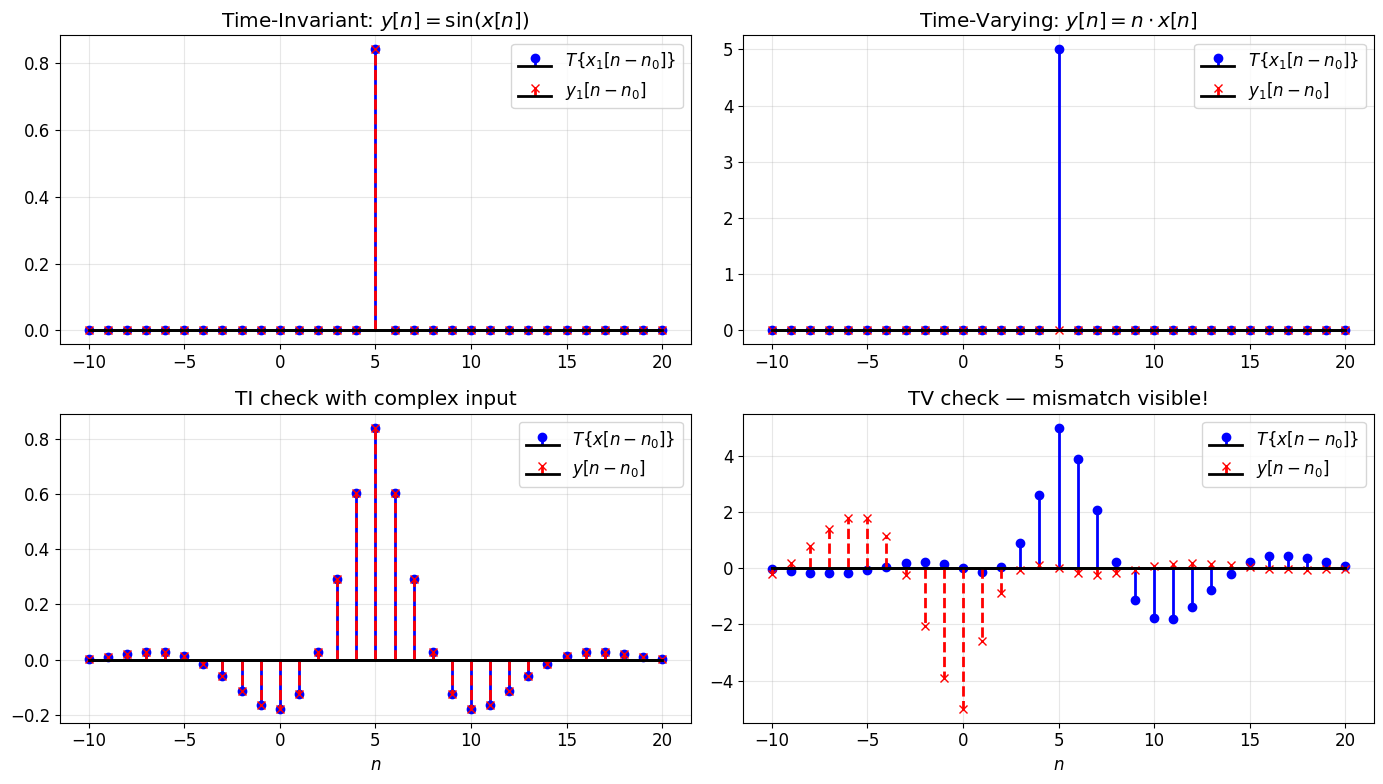

시불변 시스템 — y2[n] == y1[n-n0]: True
시변 시스템 — y2[n] == y1[n-n0]: False


In [12]:
n = np.arange(-10, 21)
n0 = 5  # 시간 이동량

x1 = delta(n)   # x1[n] = δ[n]
x2 = delta(n - n0)  # x2[n] = δ[n - n0] = x1[n - n0]

# 시불변 시스템: y[n] = sin(x[n])
def ti_sys(x):
    return np.sin(x)

# 시변 시스템: y[n] = n * x[n]
def tv_sys(x, n):
    return n * x

# --- 시불변 시스템 검증 ---
y1_ti = ti_sys(x1)  # y1[n]
y2_ti = ti_sys(x2)  # y2[n] = T{x2[n]} = T{x1[n-n0]}

# y1[n-n0]을 만들려면 인덱스 shift
y1_shifted_ti = ti_sys(delta(n - n0))  # y1을 n0만큼 이동

# --- 시변 시스템 검증 ---
y1_tv = tv_sys(x1, n)   # y1[n] = n * δ[n] = 0
y2_tv = tv_sys(x2, n)   # y2[n] = n * δ[n-n0] = n0 * δ[n-n0]
y1_shifted_tv = tv_sys(delta(n - n0), n - n0)  # y1[n-n0] = (n-n0)*δ[n-n0] = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].stem(n, y2_ti, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$T\{x_1[n-n_0]\}$')
axes[0, 0].stem(n, y1_shifted_ti, linefmt='r--', markerfmt='rx', basefmt='k-', label=r'$y_1[n-n_0]$')
axes[0, 0].set_title('Time-Invariant: $y[n] = \sin(x[n])$')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].stem(n, y2_tv, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$T\{x_1[n-n_0]\}$')
axes[0, 1].stem(n, y1_shifted_tv, linefmt='r--', markerfmt='rx', basefmt='k-', label=r'$y_1[n-n_0]$')
axes[0, 1].set_title('Time-Varying: $y[n] = n \cdot x[n]$')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 더 흥미로운 입력으로 재확인
x_input = np.exp(-0.3 * np.abs(n)) * np.cos(0.5 * n)
x_input_shifted = np.exp(-0.3 * np.abs(n - n0)) * np.cos(0.5 * (n - n0))

# 시불변
axes[1, 0].stem(n, ti_sys(x_input_shifted), linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$T\{x[n-n_0]\}$')
axes[1, 0].stem(n, ti_sys(x_input_shifted), linefmt='r--', markerfmt='rx', basefmt='k-', label=r'$y[n-n_0]$')
axes[1, 0].set_title('TI check with complex input')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel('$n$')

# 시변
axes[1, 1].stem(n, tv_sys(x_input_shifted, n), linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$T\{x[n-n_0]\}$')
axes[1, 1].stem(n, tv_sys(x_input, n - n0), linefmt='r--', markerfmt='rx', basefmt='k-', label=r'$y[n-n_0]$')
axes[1, 1].set_title('TV check — mismatch visible!')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('$n$')

plt.tight_layout()
plt.show()

print(f"시불변 시스템 — y2[n] == y1[n-n0]: {np.allclose(y2_ti, y1_shifted_ti)}")
print(f"시변 시스템 — y2[n] == y1[n-n0]: {np.allclose(y2_tv, y1_shifted_tv)}")

### 예제 4-3: BIBO 안정성 (Stability)

**BIBO (Bounded Input Bounded Output) 안정성**: 유한한 입력 → 항상 유한한 출력

- $y(t) = e^{x(t)}$: **안정** — $|x(t)| < B$ → $e^{-B} < y(t) < e^{B}$
- $y(t) = t \cdot x(t)$: **불안정** — 상수 입력 $x(t)=1$ → $y(t)=t$ (unbounded)

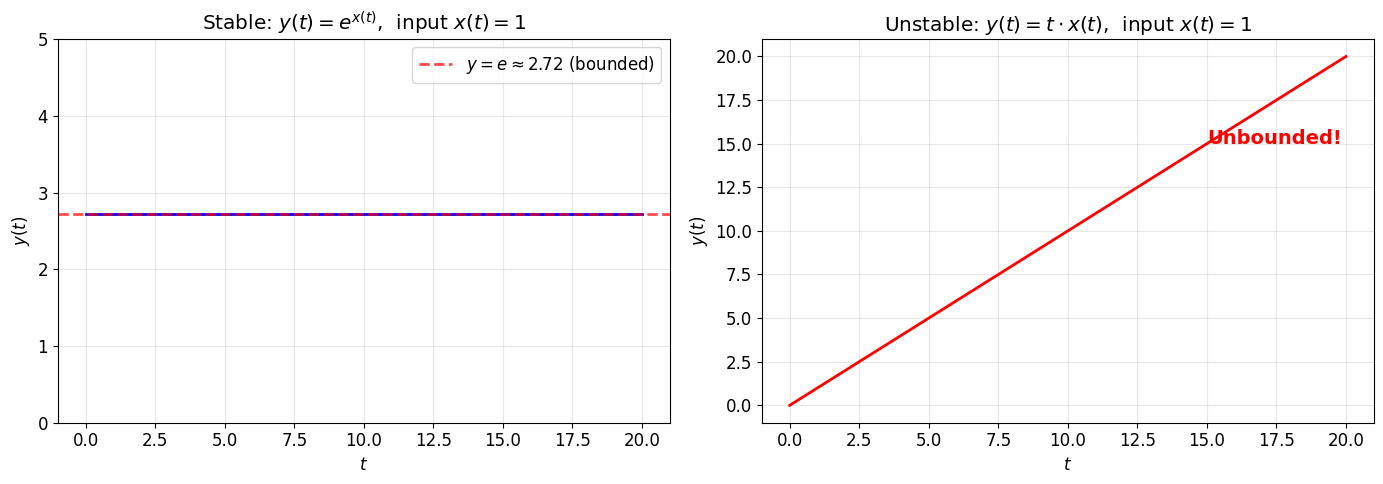

→ 안정 시스템: 유한 입력에 대해 출력이 항상 유한
→ 불안정 시스템: 유한 입력인데도 출력이 무한대로 발산


In [13]:
t = np.linspace(0, 20, 1000)
x_bounded = np.ones_like(t)  # 유한 입력: x(t) = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 안정 시스템: y(t) = e^{x(t)}
y_stable = np.exp(x_bounded)
axes[0].plot(t, y_stable, 'b-', linewidth=2)
axes[0].set_title(r'Stable: $y(t) = e^{x(t)}$,  input $x(t)=1$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$y(t)$')
axes[0].set_ylim(0, 5)
axes[0].axhline(y=np.e, color='r', linestyle='--', alpha=0.7, label=f'$y = e \\approx {np.e:.2f}$ (bounded)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 불안정 시스템: y(t) = t * x(t)
y_unstable = t * x_bounded
axes[1].plot(t, y_unstable, 'r-', linewidth=2)
axes[1].set_title(r'Unstable: $y(t) = t \cdot x(t)$,  input $x(t)=1$')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$y(t)$')
axes[1].annotate('Unbounded!', xy=(15, 15), fontsize=14, color='red', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ 안정 시스템: 유한 입력에 대해 출력이 항상 유한")
print("→ 불안정 시스템: 유한 입력인데도 출력이 무한대로 발산")

---
## 5. LTI 시스템과 컨볼루션 (Week 6)

### 5.1 LTI 시스템이 중요한 이유

- 많은 물리 시스템은 **선형(Linear)** 이면서 **시불변(Time-Invariant)** 합니다.
- LTI 시스템의 출력은 **컨볼루션(Convolution)** 으로 구할 수 있습니다.

### 5.2 컨볼루션 합 (Convolution Sum)

$$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k]$$

여기서 $h[n]$은 **임펄스 응답 (Impulse Response)**: $\delta[n]$을 입력했을 때의 출력입니다.

> **핵심**: LTI 시스템은 임펄스 응답 $h[n]$만 알면 **어떤 입력에 대해서든** 출력을 계산할 수 있습니다!

### 컨볼루션 계산 과정
1. $h[k]$를 뒤집어서 $h[-k]$ 를 만듦
2. $n$만큼 이동시켜 $h[n-k]$ 를 얻음
3. $x[k] \cdot h[n-k]$의 합을 구함
4. $n$을 변화시키며 반복

### 예제 5-1: 컨볼루션 직접 계산

교재 예제와 유사하게, 유한 길이 신호의 컨볼루션을 직접 계산하고 시각화합니다.

$$x[n] = \begin{cases} 1, & 0 \leq n \leq 4 \\ 0, & \text{otherwise} \end{cases}, \qquad h[n] = \begin{cases} \alpha^n, & 0 \leq n \leq 6 \\ 0, & \text{otherwise} \end{cases}$$

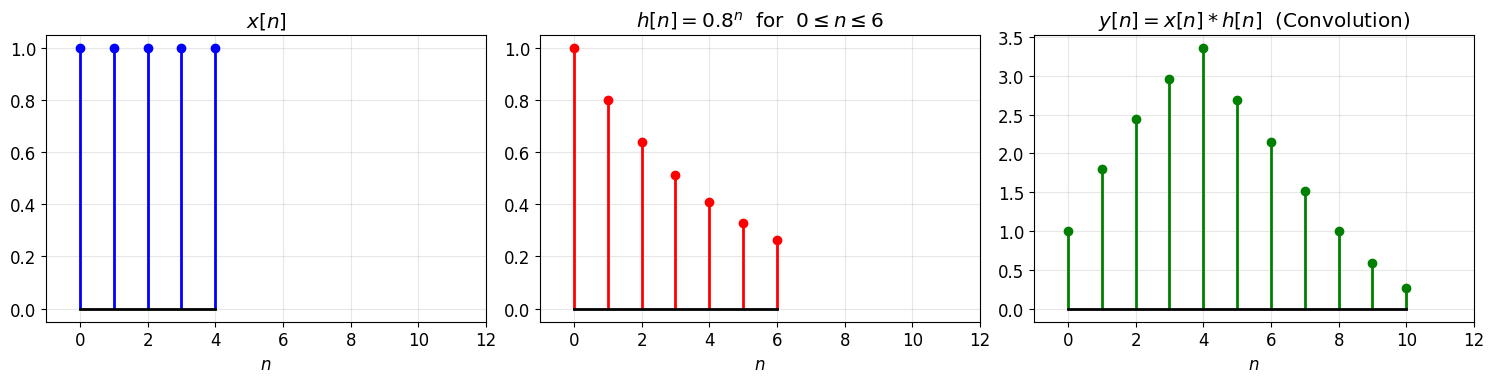

x[n] 길이: 5, h[n] 길이: 7
y[n] 길이: 11 = 5 + 7 - 1
→ 컨볼루션 결과의 길이 = len(x) + len(h) - 1


In [15]:
alpha = 0.8

# x[n]과 h[n] 정의
n_x = np.arange(0, 5)   # x는 n=0..4에서 1
x_vals = np.ones(5)

n_h = np.arange(0, 7)   # h는 n=0..6에서 alpha^n
h_vals = alpha ** n_h

# numpy의 convolve 사용
y_vals = np.convolve(x_vals, h_vals)
n_y = np.arange(0, len(y_vals))  # y의 인덱스 범위: 0 ~ 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].stem(n_x, x_vals, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title('$x[n]$')
axes[0].set_xlabel('$n$')
axes[0].set_xlim(-1, 12)
axes[0].grid(True, alpha=0.3)

axes[1].stem(n_h, h_vals, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(f'$h[n] = {alpha}^n$  for  $0 \leq n \leq 6$')
axes[1].set_xlabel('$n$')
axes[1].set_xlim(-1, 12)
axes[1].grid(True, alpha=0.3)

axes[2].stem(n_y, y_vals, linefmt='g-', markerfmt='go', basefmt='k-')
axes[2].set_title('$y[n] = x[n] * h[n]$  (Convolution)')
axes[2].set_xlabel('$n$')
axes[2].set_xlim(-1, 12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"x[n] 길이: {len(x_vals)}, h[n] 길이: {len(h_vals)}")
print(f"y[n] 길이: {len(y_vals)} = {len(x_vals)} + {len(h_vals)} - 1")
print("→ 컨볼루션 결과의 길이 = len(x) + len(h) - 1")

### 예제 5-2: 컨볼루션 과정 시각화 (Sliding Window)

컨볼루션의 핵심 아이디어를 **슬라이딩 윈도우** 방식으로 시각화합니다.

$y[n] = \sum_k x[k]\,h[n-k]$에서 $n$을 변화시키면서 $h[n-k]$(뒤집고 이동한 임펄스 응답)가 $x[k]$와 겹치는 영역을 관찰합니다.

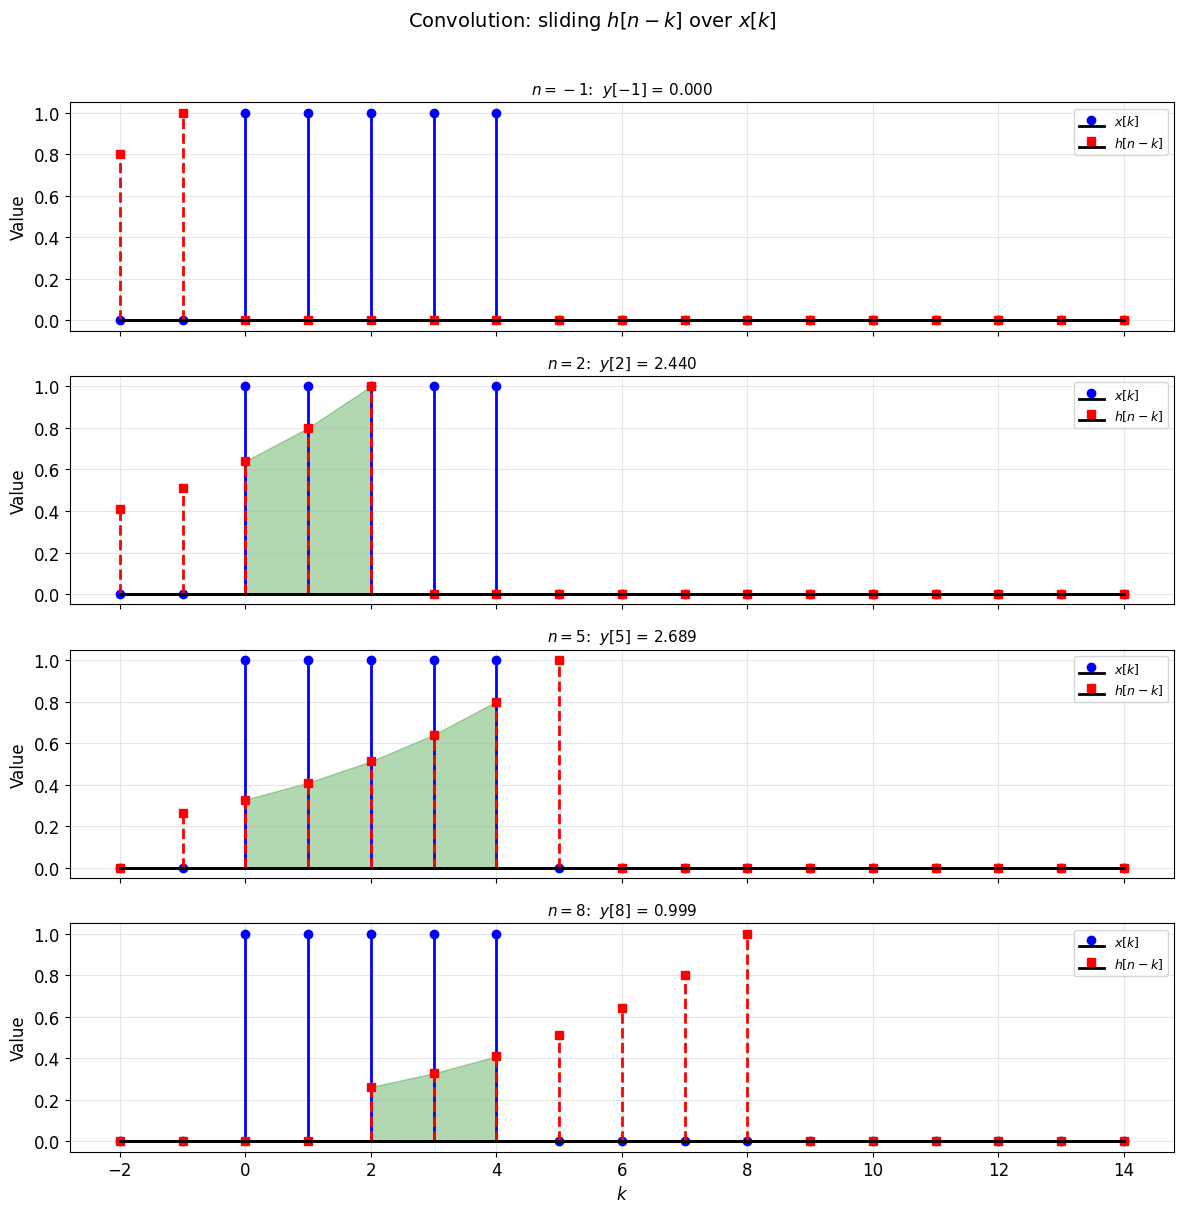

→ n이 변하면서 h[n-k]가 이동하고, x[k]와의 겹침(곱의 합)이 y[n]이 됨
→ 이것이 컨볼루션의 핵심 동작 원리!


In [16]:
alpha = 0.8

# 유한 구간에서 x, h 정의
K = 15
k_range = np.arange(-2, K)

def x_func(n):
    return np.where((n >= 0) & (n <= 4), 1.0, 0.0)

def h_func(n):
    return np.where((n >= 0) & (n <= 6), alpha ** n, 0.0)

# 여러 n 값에 대해 시각화
n_values = [-1, 2, 5, 8]

fig, axes = plt.subplots(len(n_values), 1, figsize=(12, 3 * len(n_values)), sharex=True)

for idx, n_val in enumerate(n_values):
    ax = axes[idx]
    
    x_k = x_func(k_range)
    h_nk = h_func(n_val - k_range)  # h[n-k]
    product = x_k * h_nk
    y_n = np.sum(product)
    
    ax.stem(k_range, x_k, linefmt='b-', markerfmt='bo', basefmt='k-', label='$x[k]$')
    ax.stem(k_range, h_nk, linefmt='r--', markerfmt='rs', basefmt='k-', label='$h[n-k]$')
    
    # 겹치는 부분 강조
    overlap = np.where((x_k > 0) & (h_nk > 0))[0]
    if len(overlap) > 0:
        ax.fill_between(k_range[overlap], 0, np.minimum(x_k[overlap], h_nk[overlap]), alpha=0.3, color='green')
    
    ax.set_title(f'$n = {n_val}$:  $y[{n_val}]$ = {y_n:.3f}', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('$k$')
plt.suptitle('Convolution: sliding $h[n-k]$ over $x[k]$', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("→ n이 변하면서 h[n-k]가 이동하고, x[k]와의 겹침(곱의 합)이 y[n]이 됨")
print("→ 이것이 컨볼루션의 핵심 동작 원리!")

### 예제 5-3: LTI 시스템 — 임펄스 응답으로 시스템 완전 특성화

LTI 시스템의 핵심: $h[n]$만 알면 어떤 입력이든 출력을 구할 수 있습니다.

아래 예제에서 같은 임펄스 응답 $h[n]$에 대해 서로 다른 입력을 넣어봅니다.

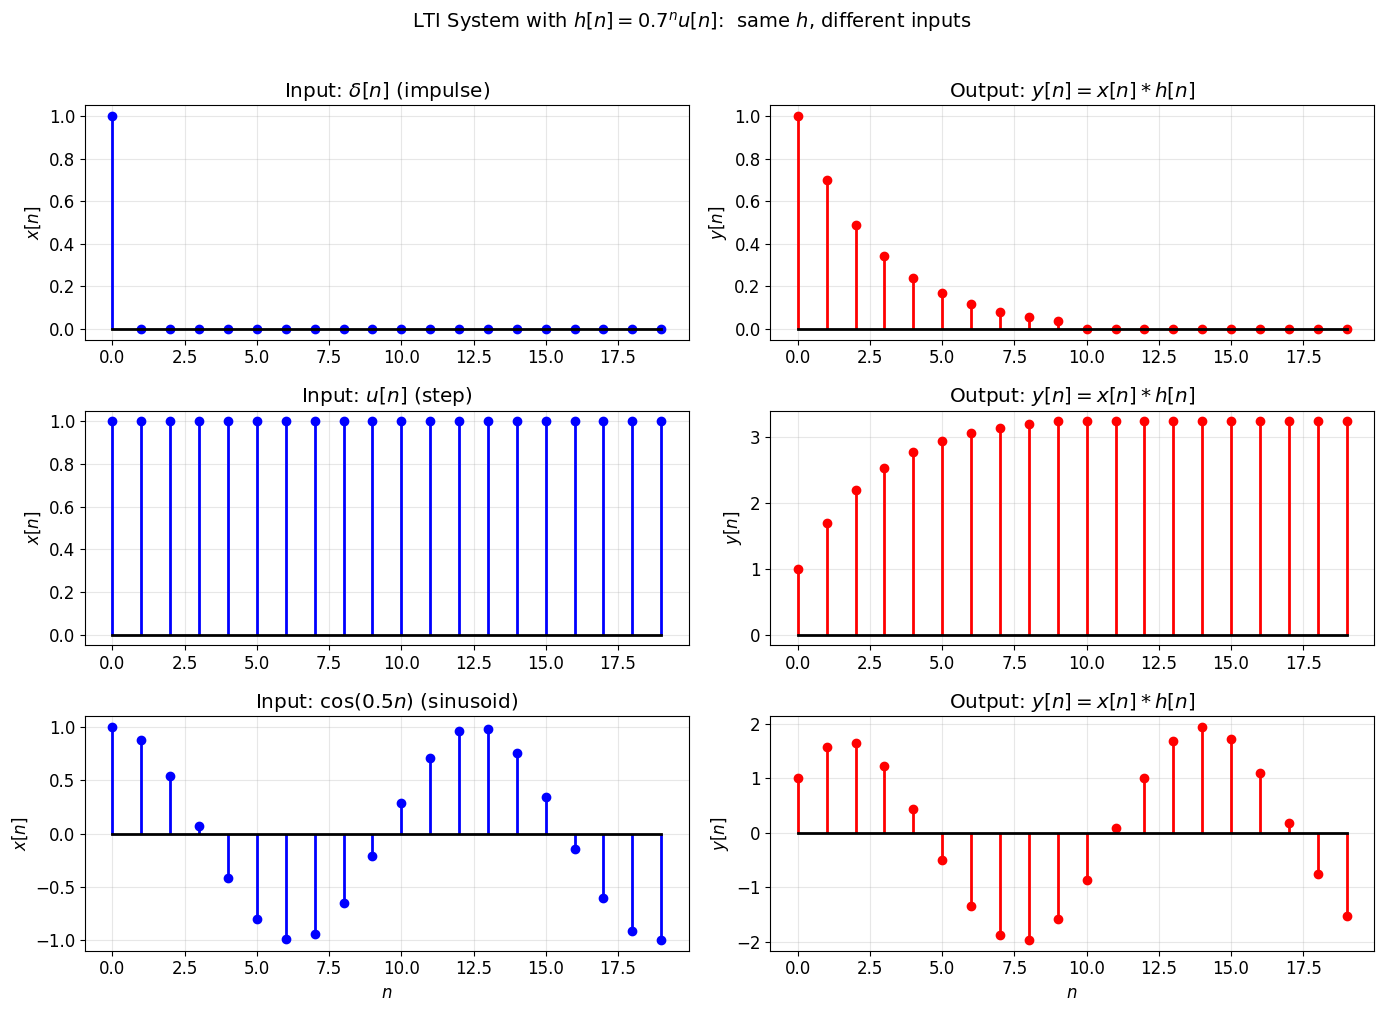

→ 임펄스 입력(δ[n])에 대한 출력이 바로 h[n] 자체임을 확인!
→ h[n]만 알면 어떤 입력에 대해서든 출력 계산 가능 — 이것이 LTI 시스템의 힘!


In [17]:
# 임펄스 응답: 감쇠하는 지수함수
n_h = np.arange(0, 10)
h = 0.7 ** n_h

# 입력 1: 단위 임펄스
n1 = np.arange(0, 20)
x1 = delta(n1)

# 입력 2: 단위 계단
x2 = unit_step(n1)

# 입력 3: 정현파
x3 = np.cos(0.5 * n1)

# 컨볼루션
y1 = np.convolve(x1, h)[:len(n1)]
y2 = np.convolve(x2, h)[:len(n1)]
y3 = np.convolve(x3, h)[:len(n1)]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

inputs = [x1, x2, x3]
outputs = [y1, y2, y3]
input_labels = [r'$\delta[n]$ (impulse)', r'$u[n]$ (step)', r'$\cos(0.5n)$ (sinusoid)']

for i, (x_in, y_out, lbl) in enumerate(zip(inputs, outputs, input_labels)):
    axes[i, 0].stem(n1, x_in, linefmt='b-', markerfmt='bo', basefmt='k-')
    axes[i, 0].set_title(f'Input: {lbl}')
    axes[i, 0].set_ylabel('$x[n]$')
    axes[i, 0].grid(True, alpha=0.3)
    
    axes[i, 1].stem(n1, y_out, linefmt='r-', markerfmt='ro', basefmt='k-')
    axes[i, 1].set_title(f'Output: $y[n] = x[n] * h[n]$')
    axes[i, 1].set_ylabel('$y[n]$')
    axes[i, 1].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('$n$')

plt.suptitle(r'LTI System with $h[n] = 0.7^n u[n]$:  same $h$, different inputs', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("→ 임펄스 입력(δ[n])에 대한 출력이 바로 h[n] 자체임을 확인!")
print("→ h[n]만 알면 어떤 입력에 대해서든 출력 계산 가능 — 이것이 LTI 시스템의 힘!")

---
## 정리

| 주제 | 핵심 포인트 |
|------|-------------|
| **오일러 공식** | $e^{j\omega_0 t} = \cos(\omega_0 t) + j\sin(\omega_0 t)$ — 복소 지수와 정현파의 연결 |
| **일반 복소 지수** | $Ce^{at}$ → $r > 0$: 증가, $r = 0$: 순수 정현파, $r < 0$: 감소 |
| **이산시간 주기성** | $\omega_0$에 $2\pi$ 주기성 존재, $\omega_0/(2\pi)$가 유리수일 때만 주기 |
| **임펄스 & 계단** | $\delta[n] = u[n] - u[n-1]$,  모든 신호 = 임펄스의 가중합 |
| **시스템 성질** | 선형성, 시불변성, 인과성, BIBO 안정성 |
| **LTI & 컨볼루션** | $y[n] = x[n] * h[n]$ — 임펄스 응답 하나로 시스템 완전 특성화 |

---
*End of Week 3, 5, 6 Practice Notebook*